In [10]:
import xarray as xr
import isku_utils
import cdsapi

import numpy as np
import geopandas as gpd
from scipy.stats import norm
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]

# Load Data

In [9]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [11]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [2]:
# Define Forecast Months
fc_months = [8, 9, 10, 11, 12, 1]

In [4]:
## CMIP6 Projections
ar6_project = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_ssp370_mon_201501-210012.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)
ar6_hist = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_historical_mon_185001-201412.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/tmp/ipykernel_51094/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/tmp/ipykernel_51094/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.70

In [5]:
# IPCC Recent Baseline Period 1995-2014
hist_mean = (
    ar6_hist["t"]
    .sel(time=slice("1995-01-01", "2014-12-31"))
    .groupby("time.month")
    .mean()
)
hist_mean = hist_mean.sel(month=fc_months).mean(dim="member").compute()

In [6]:
projection = ar6_project["t"]
projection = projection.assign_coords(
    year=projection.time.dt.year, month=projection.time.dt.month
)
projection = projection.set_index(time=["year", "month"]).unstack("time")
projection = projection.sel(month=fc_months).mean(dim=["member"]).compute()

In [7]:
### Seasonal Forecast ###
# Raw Forecast/Hindcast
s51 = xr.open_zarr(
    "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"
)
forecast = (
    s51.sel(time=slice("2026-08-01", "2027-01-31"))
    .groupby("time.month")
    .mean()
    .compute()
)
hindcast = (
    s51.sel(time=slice("1995-08-01", "2014-01-31"))
    .groupby("time.month")
    .mean()
    .sel(month=[1, 8, 9, 10, 11, 12])
    .mean(dim="number")
    .compute()
)

In [8]:
## Clean statistics
projection = projection.interpolate_na(dim="lat", method="linear")
hist_mean = hist_mean.interpolate_na(dim="lat", method="linear")

# Climate Projection: Get "annual 6-month anomaly"
mean_proj = projection.mean(dim="month")
mean_base = hist_mean.mean(dim="month")

anomaly_proj = mean_proj - mean_base
anomaly_proj_smooth = anomaly_proj.rolling(year=10, center=False, min_periods=10).mean()

# Forecast anomaly
anomaly_fc = forecast["tas"] - hindcast["tas"]
## Move to Impact Regions
projection_anomaly_ir = isku_utils.grid_to_ir(anomaly_proj_smooth)
forecast_ir_anomaly = isku_utils.grid_to_ir(anomaly_fc)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [12]:
#Pop-Weighted Average
merged_projection = xr.merge([projection_anomaly_ir.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([forecast_ir_anomaly.rename('anomaly'), socioeconomics])

pop_weighted_anomaly_projection = (merged_projection['anomaly'] * merged_projection['pop']).sum(dim='region') / merged_projection['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

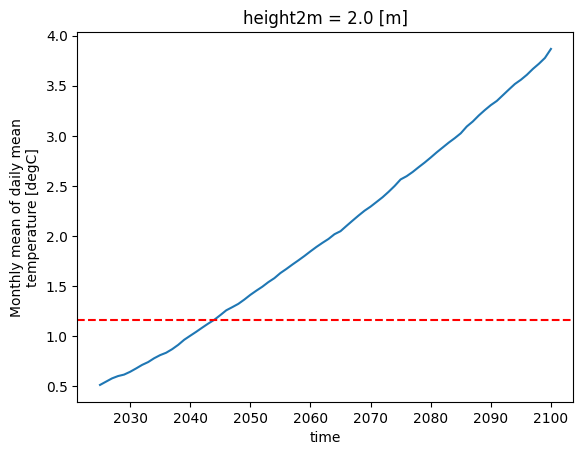

In [30]:
pop_weighted_anomaly_projection.sel(year = slice(2025, None)).plot()
plt.axhline(pop_weighted_anomaly_forecast.mean(dim = ['month', 'number']).values, color = 'red', linestyle = '--', label = 'Forecast Mean')


In [25]:
comp = (pop_weighted_anomaly_projection< pop_weighted_anomaly_forecast.mean(dim = ['month', 'number']).values)

In [27]:
pop_weighted_anomaly_projection.where(comp).idxmax(dim = 'year').values

array(2043.)